In [7]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Categories and payment modes
categories = ["Food", "Travel", "Shopping", "Bills", "Entertainment", "Health"]
payment_modes = ["UPI", "Card", "Cash"]

# Generate synthetic data
data = []

start_date = datetime(2025, 1, 1)

for i in range(500):
    date = start_date + timedelta(days=random.randint(0, 365))
    category = random.choice(categories)
    payment = random.choice(payment_modes)
    amount = round(random.uniform(50, 5000), 2)

    data.append([i+1, date.date(), category, payment, amount])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "transaction_id",
    "date",
    "category",
    "payment_mode",
    "amount"
])

# Save dataset
df.to_csv("data/transactions.csv", index=False)


print("Dataset Created Successfully")



Dataset Created Successfully


In [8]:
df = pd.read_csv("data/transactions.csv")
df.head()

,transaction_id,date,category,payment_mode,amount
0,1,2025-07-08,Food,Cash,2332.83
1,2,2025-06-28,Bills,Card,790.65
2,3,2025-01-27,Shopping,Cash,2703.88
3,4,2025-12-02,Shopping,UPI,787.03
4,5,2025-02-18,Travel,Cash,152.81


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  500 non-null    int64  
 1   date            500 non-null    object 
 2   category        500 non-null    object 
 3   payment_mode    500 non-null    object 
 4   amount          500 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 19.7+ KB


In [10]:
df.describe()


,transaction_id,amount
count,500.000000,500.000000
mean,250.500000,2515.320180
std,144.481833,1447.606645
min,1.000000,55.070000
25%,125.750000,1216.170000
50%,250.500000,2610.900000
75%,375.250000,3769.162500
max,500.000000,4983.540000


In [11]:
df.groupby("category")["amount"].sum()


category
Bills            227989.04
Entertainment    193640.90
Food             207792.68
Health           230751.50
Shopping         194259.57
Travel           203226.40
Name: amount, dtype: float64

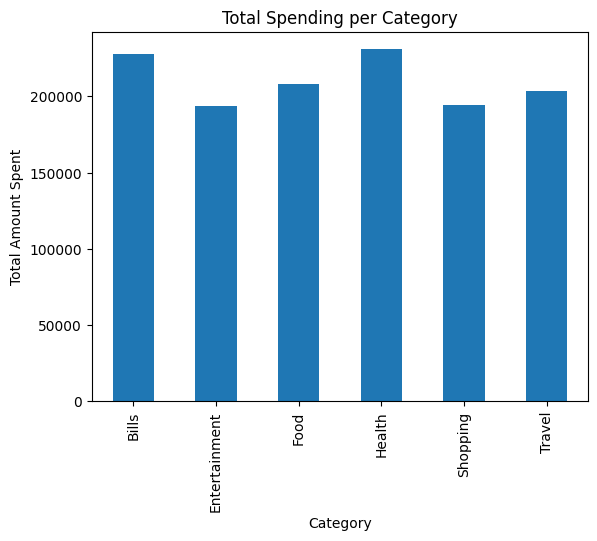

In [12]:
import matplotlib.pyplot as plt

category_spend = df.groupby("category")["amount"].sum()

category_spend.plot(kind="bar")

plt.title("Total Spending per Category")
plt.xlabel("Category")
plt.ylabel("Total Amount Spent")

plt.show()


In [13]:
df["date"] = pd.to_datetime(df["date"])


In [14]:
df["month"] = df["date"].dt.month
df.head()


,transaction_id,date,category,payment_mode,amount,month
0,1,2025-07-08,Food,Cash,2332.83,7
1,2,2025-06-28,Bills,Card,790.65,6
2,3,2025-01-27,Shopping,Cash,2703.88,1
3,4,2025-12-02,Shopping,UPI,787.03,12
4,5,2025-02-18,Travel,Cash,152.81,2


In [15]:
monthly_spend = df.groupby("month")["amount"].sum()
monthly_spend


month
1     120129.87
2      92139.16
3      86455.76
4     140584.53
5      85230.49
6      87677.07
7     108256.29
8      96515.07
9      93854.06
10    118223.95
11    117751.30
12    110842.54
Name: amount, dtype: float64

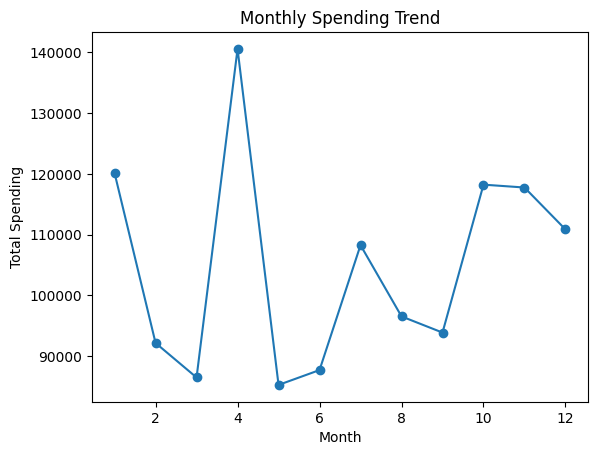

In [16]:
monthly_spend.plot(kind="line", marker="o")

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")

plt.show()


In [17]:
# Recalculate everything inside one cell (safe execution)

total_spend = df["amount"].sum()

category_spend = df.groupby("category")["amount"].sum()

category_percentage = (category_spend / total_spend) * 100

overspend_categories = category_percentage[category_percentage > 20]

overspend_categories

Series([], Name: amount, dtype: float64)

In [18]:
df["date"] = pd.to_datetime(df["date"])  # safety
df["day_of_week"] = df["date"].dt.day_name()
df.head()
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])
df.head()
weekend_spend = df.groupby("is_weekend")["amount"].sum()
weekend_spend
weekend_percentage = (weekend_spend / df["amount"].sum()) * 100
weekend_percentage

is_weekend
False    69.454039
True     30.545961
Name: amount, dtype: float64

In [19]:
avg_spend = df.groupby("is_weekend")["amount"].mean()
avg_spend

is_weekend
False    2446.766751
True     2686.464056
Name: amount, dtype: float64

In [20]:
df["amount"].describe()
df.head()
threshold = df["amount"].quantile(0.9)
print(threshold)

4482.615


In [21]:
df["high_value"] = df["amount"] > 4483.088
df["high_value"].value_counts()
(df["high_value"].mean()) * 100


np.float64(10.0)

In [22]:
df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])
df.head()
df.groupby("is_weekend")["high_value"].mean() * 100

is_weekend
False     9.803922
True     10.489510
Name: high_value, dtype: float64

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload dataset fresh
df = pd.read_csv("data/transactions.csv")

# Force-create columns
df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

threshold = df["amount"].quantile(0.9)
df["high_value"] = df["amount"] > threshold

# DEBUG PRINT
print(df.columns)

Index(['transaction_id', 'date', 'category', 'payment_mode', 'amount',
       'day_of_week', 'is_weekend', 'high_value'],
      dtype='object')


In [24]:
df.groupby("is_weekend")["high_value"].mean() * 100
## Behaviour Analysis Insights

##1. Weekend spending contributes ~25–26% of total expenditure, slightly below proportional expectation (~28.5%).

#2. Average transaction value is higher on weekdays than weekends.

#3. High-value transactions (>90th percentile) are more frequent on weekdays (10.47%) compared to weekends (8.76%), indicating that major expenses are concentrated during weekdays.

is_weekend
False     9.803922
True     10.489510
Name: high_value, dtype: float64